# 한 학생, 한 문항으로 배우는 문항반응이론(IRT) 입문

이 노트북은 통계를 깊이 배우지 않은 분을 위한 입문용 자료입니다.
수식은 꼭 필요한 것만 쓰고, 그림과 예시로 설명합니다.
(같은 내용을 더 자세히 다룬 심화용 노트북은 `irt_1item_1person.ipynb` 입니다.)

## 이 노트북에서 배우는 것

1. 학생의 **능력**과 문항의 **난도**로 정답 확률을 계산하는 방법
2. 문항의 난도를 **알 때**와 **모를 때**, 학생 능력의 추정 결과가 어떻게 달라지는지
3. 우리가 미리 가진 생각(**사전분포**)이 결과에 주는 영향
4. 이 학생이 **새 문항 10개**를 풀면 몇 개를 맞힐지 예측하는 방법

## 먼저 알아 둘 용어

| 기호 | 이름 | 뜻 |
|---|---|---|
| $\theta$ (세타) | 잠재능력 | 학생의 실력. 눈에 보이지 않아서 '잠재'라고 부릅니다. 클수록 실력이 좋습니다. |
| $\delta$ (델타) | 잠재난도 | 문항의 어려운 정도. 클수록 어려운 문항입니다. |
| $\phi$ (파이) | 정답 확률 | 이 학생이 이 문항을 맞힐 확률. 0과 1 사이의 값입니다. |
| 사전분포 | prior | 데이터를 보기 **전에** 가진 생각. "보통 학생이라면 능력이 이 정도일 것이다." |
| 사후분포 | posterior | 데이터를 본 **뒤에** 고친 생각. 우리가 구하려는 답입니다. |

## 1. 상황 설정

한 학생이 국어 문법 문항 하나를 **20번** 풉니다. 맞히면 1점, 틀리면 0점입니다.
(학생이 앞에서 푼 내용을 기억하지 못한다고 가정합니다. 난도가 똑같은 문항 20개를 푼다고 생각해도 됩니다.)

정답 확률은 학생의 능력과 문항의 난도로 정해집니다.

$$
\phi = \text{logistic}(\theta - \delta) = \frac{1}{1 + e^{-(\theta - \delta)}}
$$

이 식은 이렇게 읽으면 됩니다.

- **능력에서 난도를 뺀 값**($\theta - \delta$)이 클수록 정답 확률이 높아집니다.
- 능력과 난도가 같으면($\theta - \delta = 0$) 정답 확률은 정확히 50%입니다.
- logistic 함수는 어떤 수든 0과 1 사이의 확률로 바꿔 주는 함수입니다.

아래 그림으로 확인해 봅시다.

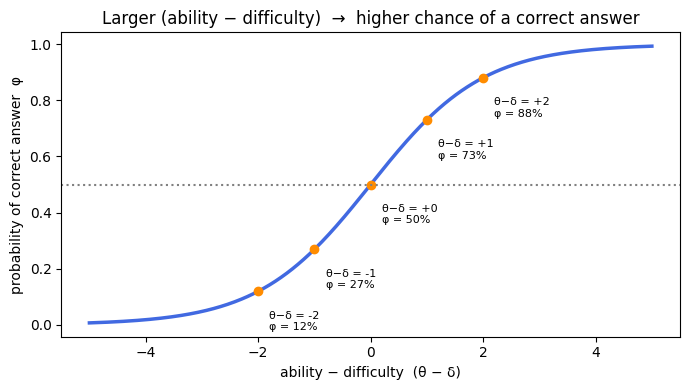

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from cmdstanpy import CmdStanModel

def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

gap = np.linspace(-5, 5, 400)          # 능력 - 난도

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(gap, logistic(gap), color="royalblue", linewidth=2.5)
for g in [-2, -1, 0, 1, 2]:
    ax.plot(g, logistic(g), "o", color="darkorange")
    ax.annotate(f"θ−δ = {g:+d}\nφ = {logistic(g):.0%}", (g, logistic(g)),
                textcoords="offset points", xytext=(8, -28), fontsize=8)
ax.axhline(0.5, color="gray", linestyle=":")
ax.set_xlabel("ability − difficulty  (θ − δ)")
ax.set_ylabel("probability of correct answer  φ")
ax.set_title("Larger (ability − difficulty)  →  higher chance of a correct answer")
plt.tight_layout()
plt.show()

그림에서 보듯이 능력이 난도보다 1만큼 높으면 정답 확률은 약 73%, 2만큼 높으면 약 88%입니다.
반대로 능력이 난도보다 낮으면 정답 확률은 50%보다 낮아집니다.

## 2. 가상 데이터 만들기

실제 학생의 능력은 아무도 모릅니다. 그래서 여기서는 컴퓨터로 **가상의 학생**을 만듭니다.

- 이 학생의 진짜 능력은 $\theta = 1.2$, 문항의 진짜 난도는 $\delta = 0.7$ 이라고 정합니다.
- 이 값으로 20번의 정답·오답을 만듭니다.
- 진짜 값은 **정답지처럼 컴퓨터만 알고 있다**고 생각하세요. 추정할 때는 0과 1로 된 응답 기록만 사용합니다.
- 진짜 값은 마지막에 추정이 잘되었는지 채점할 때만 꺼내 봅니다.

In [2]:
SEED = 2026
rng = np.random.default_rng(SEED)

# ----- 정답지 (추정할 때는 사용하지 않습니다) -----
THETA_TRUE = 1.2     # 학생의 진짜 능력
DELTA_TRUE = 0.7     # 문항의 진짜 난도
PHI_TRUE = logistic(THETA_TRUE - DELTA_TRUE)
print(f"진짜 정답 확률 φ = logistic({THETA_TRUE} - {DELTA_TRUE}) = {PHI_TRUE:.3f}")

# ----- 20번 풀기 -----
N = 20
y = rng.binomial(n=1, p=PHI_TRUE, size=N)
k = int(y.sum())
print("응답 기록:", y)
print(f"{N}번 중 {k}번 맞힘 (정답률 {k/N:.0%})")

진짜 정답 확률 φ = logistic(1.2 - 0.7) = 0.622
응답 기록: [1 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1]
20번 중 11번 맞힘 (정답률 55%)


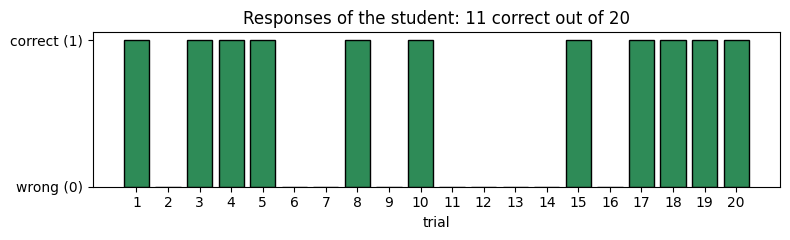

In [3]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.bar(np.arange(1, N + 1), y, color=["seagreen" if v == 1 else "lightgray" for v in y], edgecolor="black")
ax.set_yticks([0, 1])
ax.set_yticklabels(["wrong (0)", "correct (1)"])
ax.set_xticks(np.arange(1, N + 1))
ax.set_xlabel("trial")
ax.set_title(f"Responses of the student: {k} correct out of {N}")
plt.tight_layout()
plt.show()

진짜 정답 확률은 62%인데, 실제로는 20번 중 11번(55%)을 맞혔습니다.
동전을 20번 던져도 앞면이 늘 정확히 10번 나오지는 않는 것처럼, 횟수가 적으면 이런 차이는 흔히 생깁니다.

## 3. 추정 방법: 베이즈 추론을 한 문장으로

베이즈 추론은 **"원래 가진 생각을 데이터로 고친다"** 는 방법입니다.

$$
\text{사후분포} \;\propto\; \text{사전분포} \times \text{데이터가 나올 가능성}
$$

- **사전분포**: 데이터를 보기 전의 생각입니다. 여기서는 "학생 능력은 대체로 0 근처이고, 대부분 −2에서 2 사이"라는 생각을 씁니다. 평균 0, 표준편차 1인 정규분포 $N(0, 1)$ 입니다.
- **데이터가 나올 가능성**: 능력이 어떤 값일 때 "20번 중 11번 정답"이라는 결과가 얼마나 나올 법한지를 나타냅니다.
- **사후분포**: 두 가지를 곱해서 얻은, 데이터를 본 뒤의 생각입니다.

계산은 **Stan**이라는 프로그램이 대신합니다. Stan은 사후분포에서 값을 수천 개 뽑아 줍니다.
뽑힌 값들로 히스토그램을 그리면 사후분포의 모양을 눈으로 확인할 수 있습니다.

결과를 읽을 때는 두 가지를 봅니다.
- **평균**: 사후분포의 중심. 능력을 값 하나로 나타낼 때 씁니다.
- **95% 구간**: 진짜 값이 이 안에 있을 것이라고 95% 믿을 수 있는 범위. 좁을수록 더 확실하게 안다는 뜻입니다.

In [4]:
# 결과를 보기 쉽게 정리하는 도우미 함수
def summary_line(name, samples, true=None):
    lo, hi = np.quantile(samples, [0.025, 0.975])
    text = f"{name}: 평균 {samples.mean():.2f}, 95% 구간 [{lo:.2f}, {hi:.2f}], 구간 폭 {hi - lo:.2f}"
    if true is not None:
        text += f"  (진짜 값 {true:.2f}, 구간 안에 있음: {'예' if lo <= true <= hi else '아니오'})"
    print(text)

def fit_model(model, data):
    return model.sample(data=data, chains=4, parallel_chains=4,
                        iter_warmup=1000, iter_sampling=2000,
                        seed=SEED, show_progress=False)

## 4. 경우 1: 문항 난도를 **아는** 경우

이 문항은 예전에 많은 학생이 풀어 본 문항이라서, 난도가 $\delta = 0.7$ 이라는 것을 이미 알고 있다고 합시다.
(시험 기관의 '문항 은행'에 난도가 기록된 문항을 떠올리면 됩니다.)

그러면 모르는 것은 학생의 능력 $\theta$ 하나뿐입니다.
데이터로 "능력 − 난도"를 알아내면, 난도를 알고 있으니 능력도 바로 알 수 있습니다.

아래 Stan 코드에서
- `data` 부분: 컴퓨터에 주는 정보 (응답 기록, 난도 0.7, 사전분포)
- `parameters` 부분: 알아내고 싶은 값 (능력 θ)
- `model` 부분: 사전분포, 그리고 '정답 확률 = logistic(θ − δ)'라는 관계

In [5]:
stan_known = """
data {
  int<lower=1> N;                    // 푼 횟수
  array[N] int<lower=0,upper=1> y;   // 응답 기록 (0 또는 1)
  real delta;                        // 알고 있는 난도
  real mu_theta;                     // 사전분포의 평균
  real<lower=0> sigma_theta;         // 사전분포의 표준편차
  int<lower=0> N_new;                // 예측할 새 문항 수
}
parameters {
  real theta;                        // 알아내고 싶은 능력
}
model {
  theta ~ normal(mu_theta, sigma_theta);   // 사전분포
  y ~ bernoulli_logit(theta - delta);      // 정답 확률 = logistic(theta - delta)
}
generated quantities {
  // 새 문항 N_new개를 풀 때 맞히는 개수 (새 문항의 난도는 평균 0, 표준편차 1에서 뽑음)
  int k_new = 0;
  for (j in 1:N_new) {
    k_new += bernoulli_logit_rng(theta - normal_rng(0, 1));
  }
}
"""
with open("irt_intro_known.stan", "w", encoding="utf-8") as f:
    f.write(stan_known)
model_known = CmdStanModel(stan_file="irt_intro_known.stan")

N_NEW = 10
fit_known = fit_model(model_known, {"N": N, "y": y.tolist(), "delta": DELTA_TRUE,
                                    "mu_theta": 0.0, "sigma_theta": 1.0, "N_new": N_NEW})
theta_known = fit_known.stan_variable("theta")

summary_line("능력 θ (난도를 알 때)", theta_known, THETA_TRUE)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xed in position 50: illegal multibyte sequence

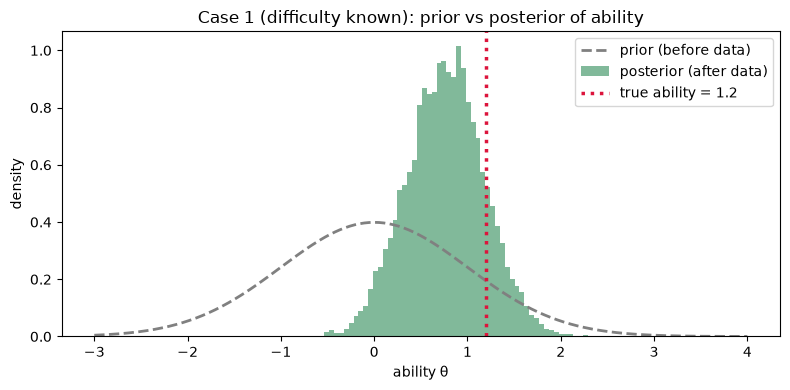

In [ ]:
grid = np.linspace(-3, 4, 400)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid, norm.pdf(grid, 0, 1), color="gray", linestyle="--", linewidth=2, label="prior (before data)")
ax.hist(theta_known, bins=60, density=True, color="seagreen", alpha=0.6, label="posterior (after data)")
ax.axvline(THETA_TRUE, color="crimson", linestyle=":", linewidth=2.5, label=f"true ability = {THETA_TRUE}")
ax.set_xlabel("ability θ")
ax.set_ylabel("density")
ax.set_title("Case 1 (difficulty known): prior vs posterior of ability")
ax.legend()
plt.tight_layout()
plt.show()

**그림 읽기**

- 회색 점선(사전분포)은 넓게 퍼져 있습니다. 데이터를 보기 전에는 능력을 잘 모른다는 뜻입니다.
- 초록색(사후분포)은 훨씬 좁아졌고 오른쪽으로 옮겨 갔습니다. 20번의 응답 기록이 능력에 대해 많은 것을 알려 주었습니다.
- 사후분포의 평균(약 0.76)은 진짜 능력(1.2)보다 조금 낮습니다. 이유는 두 가지입니다.
  - 이번 데이터에서 학생이 기대보다 조금 덜 맞혔습니다 (55% < 62%).
  - 사전분포에 담긴 "능력은 0 근처"라는 생각이 결과를 0 쪽으로 조금 끌어당겼습니다.

### 더 많이 풀면 어떻게 될까?

같은 학생이 같은 문항을 20번이 아니라 **200번** 풀었다고 해 봅시다.

200번 중 120번 맞힘 (정답률 60%)


20번 풀었을 때 : 평균 0.76, 95% 구간 [-0.04, 1.58], 구간 폭 1.61  (진짜 값 1.20, 구간 안에 있음: 예)
200번 풀었을 때: 평균 1.09, 95% 구간 [0.81, 1.36], 구간 폭 0.55  (진짜 값 1.20, 구간 안에 있음: 예)


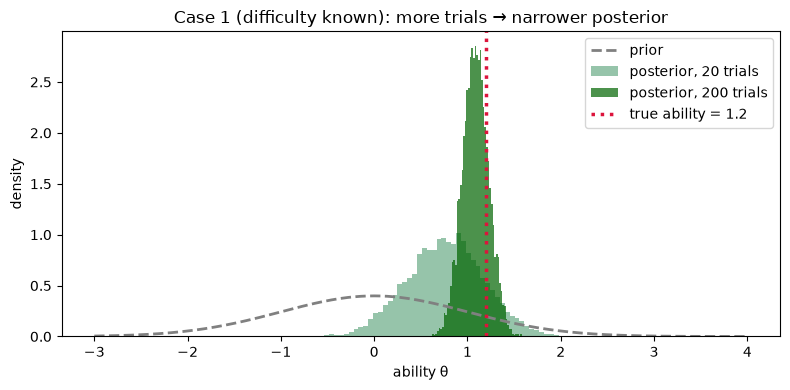

In [ ]:
N_BIG = 200
y_200 = np.random.default_rng(SEED + 200).binomial(n=1, p=PHI_TRUE, size=N_BIG)
print(f"200번 중 {y_200.sum()}번 맞힘 (정답률 {y_200.mean():.0%})")

fit_known_200 = fit_model(model_known, {"N": N_BIG, "y": y_200.tolist(), "delta": DELTA_TRUE,
                                        "mu_theta": 0.0, "sigma_theta": 1.0, "N_new": N_NEW})
theta_known_200 = fit_known_200.stan_variable("theta")

summary_line("20번 풀었을 때 ", theta_known, THETA_TRUE)
summary_line("200번 풀었을 때", theta_known_200, THETA_TRUE)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid, norm.pdf(grid, 0, 1), color="gray", linestyle="--", linewidth=2, label="prior")
ax.hist(theta_known, bins=60, density=True, color="seagreen", alpha=0.5, label="posterior, 20 trials")
ax.hist(theta_known_200, bins=60, density=True, color="darkgreen", alpha=0.7, label="posterior, 200 trials")
ax.axvline(THETA_TRUE, color="crimson", linestyle=":", linewidth=2.5, label=f"true ability = {THETA_TRUE}")
ax.set_xlabel("ability θ")
ax.set_ylabel("density")
ax.set_title("Case 1 (difficulty known): more trials → narrower posterior")
ax.legend()
plt.tight_layout()
plt.show()

**정리 (경우 1)**: 난도를 알면, 많이 풀수록 사후분포가 좁아지고 진짜 능력에 가까워집니다.
200번 풀었을 때의 구간 폭은 20번 풀었을 때의 약 3분의 1입니다.
우리가 흔히 기대하는 "데이터가 많을수록 더 정확해진다"는 생각이 그대로 들어맞습니다.

## 5. 경우 2: 문항 난도도 **모르는** 경우

이번에는 처음 쓰는 새 문항이라서 난도도 모른다고 합시다. 이제 모르는 값이 능력 $\theta$ 와 난도 $\delta$ 두 개입니다.

### 먼저 비유로 생각해 봅시다

> 철수가 영희보다 키가 **10cm 크다**는 것만 안다고 합시다.
> 이것만으로 철수의 키를 알 수 있을까요?
> 철수 170cm·영희 160cm일 수도 있고, 철수 180cm·영희 170cm일 수도 있습니다. **차이만으로는 각자의 키를 알 수 없습니다.**

우리 문제도 똑같습니다. 응답 기록이 알려 주는 것은 정답 확률, 즉 **능력과 난도의 차이**($\theta - \delta$)뿐입니다.

- "능력 1.2, 난도 0.7" → 차이 0.5
- "능력 0.5, 난도 0.0" → 차이 0.5
- "능력 2.0, 난도 1.5" → 차이 0.5

세 경우 모두 정답 확률이 같아서 응답 기록만으로는 구별할 수 없습니다.
그렇다면 능력의 사후분포는 어떻게 될까요? 실제로 계산해 봅시다.
난도에도 사전분포로 $N(0, 1)$ 을 정합니다 ("보통 문항이라면 난도는 0 근처일 것이다").

In [ ]:
stan_unknown = """
data {
  int<lower=1> N;
  array[N] int<lower=0,upper=1> y;
  real mu_theta;                     // 능력의 사전분포
  real<lower=0> sigma_theta;
  real mu_delta;                     // 난도의 사전분포
  real<lower=0> sigma_delta;
  int<lower=0> N_new;
}
parameters {
  real theta;                        // 능력 (모름)
  real delta;                        // 난도 (모름)
}
model {
  theta ~ normal(mu_theta, sigma_theta);
  delta ~ normal(mu_delta, sigma_delta);
  y ~ bernoulli_logit(theta - delta);
}
generated quantities {
  real gap = theta - delta;          // 능력과 난도의 차이
  int k_new = 0;
  for (j in 1:N_new) {
    k_new += bernoulli_logit_rng(theta - normal_rng(0, 1));
  }
}
"""
with open("irt_intro_unknown.stan", "w", encoding="utf-8") as f:
    f.write(stan_unknown)
model_unknown = CmdStanModel(stan_file="irt_intro_unknown.stan")

def fit_unknown(y_obs, mu_theta=0.0, sigma_theta=1.0, mu_delta=0.0, sigma_delta=1.0):
    return fit_model(model_unknown, {"N": len(y_obs), "y": list(map(int, y_obs)),
                                     "mu_theta": mu_theta, "sigma_theta": sigma_theta,
                                     "mu_delta": mu_delta, "sigma_delta": sigma_delta, "N_new": N_NEW})

fit_unk = fit_unknown(y)
theta_unk = fit_unk.stan_variable("theta")
delta_unk = fit_unk.stan_variable("delta")
gap_unk = fit_unk.stan_variable("gap")

summary_line("능력 θ         ", theta_unk, THETA_TRUE)
summary_line("난도 δ         ", delta_unk, DELTA_TRUE)
summary_line("차이 θ − δ     ", gap_unk, THETA_TRUE - DELTA_TRUE)

능력 θ         : 평균 0.11, 95% 구간 [-1.35, 1.58], 구간 폭 2.93  (진짜 값 1.20, 구간 안에 있음: 예)
난도 δ         : 평균 -0.09, 95% 구간 [-1.54, 1.38], 구간 폭 2.92  (진짜 값 0.70, 구간 안에 있음: 예)
차이 θ − δ     : 평균 0.19, 95% 구간 [-0.66, 1.04], 구간 폭 1.70  (진짜 값 0.50, 구간 안에 있음: 예)


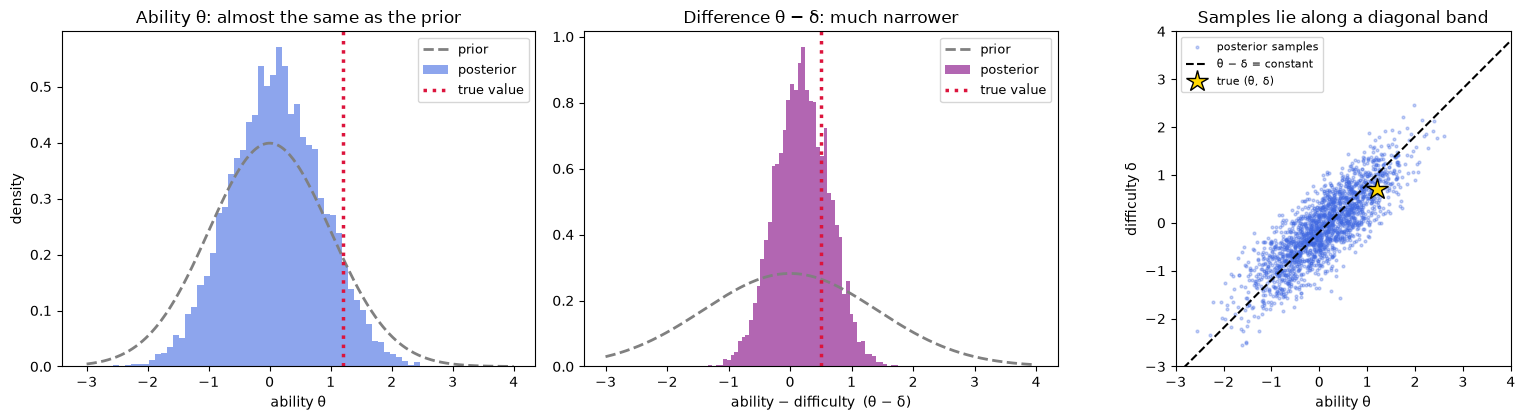

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

ax = axes[0]
ax.plot(grid, norm.pdf(grid, 0, 1), color="gray", linestyle="--", linewidth=2, label="prior")
ax.hist(theta_unk, bins=60, density=True, color="royalblue", alpha=0.6, label="posterior")
ax.axvline(THETA_TRUE, color="crimson", linestyle=":", linewidth=2.5, label="true value")
ax.set_xlabel("ability θ"); ax.set_ylabel("density")
ax.set_title("Ability θ: almost the same as the prior")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(grid, norm.pdf(grid, 0, np.sqrt(2)), color="gray", linestyle="--", linewidth=2, label="prior")
ax.hist(gap_unk, bins=60, density=True, color="purple", alpha=0.6, label="posterior")
ax.axvline(THETA_TRUE - DELTA_TRUE, color="crimson", linestyle=":", linewidth=2.5, label="true value")
ax.set_xlabel("ability − difficulty  (θ − δ)")
ax.set_title("Difference θ − δ: much narrower")
ax.legend(fontsize=9)

ax = axes[2]
idx = rng.choice(len(theta_unk), size=2000, replace=False)
ax.scatter(theta_unk[idx], delta_unk[idx], s=4, alpha=0.3, color="royalblue", label="posterior samples")
line = np.linspace(-3, 4, 10)
ax.plot(line, line - gap_unk.mean(), color="black", linestyle="--", label="θ − δ = constant")
ax.plot(THETA_TRUE, DELTA_TRUE, "*", color="gold", markeredgecolor="black", markersize=16, label="true (θ, δ)")
ax.set_xlim(-3, 4); ax.set_ylim(-3, 4); ax.set_aspect("equal")
ax.set_xlabel("ability θ"); ax.set_ylabel("difficulty δ")
ax.set_title("Samples lie along a diagonal band")
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

**그림 읽기**

- **왼쪽 (능력)**: 사후분포가 사전분포보다 조금 좁아졌을 뿐, 거의 비슷합니다. 20번의 응답 기록이 능력에 대해서는 별로 알려 주지 못했습니다.
  (경우 1에서는 같은 데이터로 구간 폭이 1.6이었는데, 여기서는 2.9입니다.)
- **가운데 (차이)**: 사후분포가 사전분포보다 훨씬 좁습니다. 데이터는 **차이**에 대해서는 많은 것을 알려 줍니다.
- **오른쪽 (능력과 난도를 함께)**: 뽑힌 값들이 대각선을 따라 길게 늘어서 있습니다.
  대각선 위의 점들은 모두 차이가 같아서 데이터로는 서로 구별되지 않습니다.
  능력이 높으면 난도도 높고, 능력이 낮으면 난도도 낮은 조합들입니다.
  대각선 위의 어디쯤인지는 데이터가 아니라 **사전분포**가 정합니다.

키 비유로 말하면, 키 차이(10cm)는 정확히 알게 되었지만 각자의 키는 여전히 모르는 상태입니다.

### 많이 풀면 해결될까?

경우 1처럼 200번을 풀면 어떻게 되는지 봅시다.

[능력 θ]
  20번 : 평균 0.11, 95% 구간 [-1.35, 1.58], 구간 폭 2.93  (진짜 값 1.20, 구간 안에 있음: 예)
  200번: 평균 0.17, 95% 구간 [-1.26, 1.62], 구간 폭 2.87  (진짜 값 1.20, 구간 안에 있음: 예)
[차이 θ − δ]
  20번 : 평균 0.19, 95% 구간 [-0.66, 1.04], 구간 폭 1.70  (진짜 값 0.50, 구간 안에 있음: 예)
  200번: 평균 0.40, 95% 구간 [0.12, 0.68], 구간 폭 0.56  (진짜 값 0.50, 구간 안에 있음: 예)


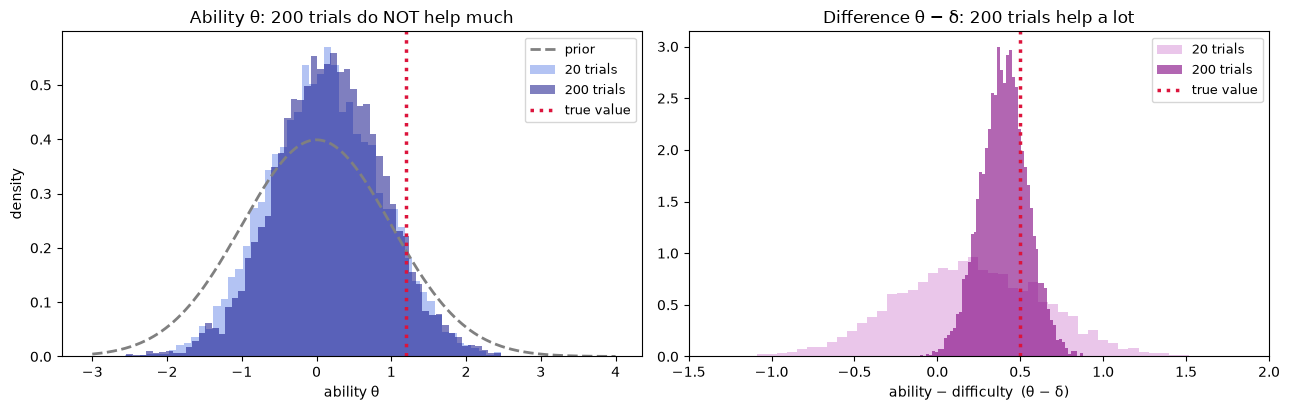

In [ ]:
fit_unk_200 = fit_unknown(y_200)
theta_unk_200 = fit_unk_200.stan_variable("theta")
gap_unk_200 = fit_unk_200.stan_variable("gap")

print("[능력 θ]")
summary_line("  20번 ", theta_unk, THETA_TRUE)
summary_line("  200번", theta_unk_200, THETA_TRUE)
print("[차이 θ − δ]")
summary_line("  20번 ", gap_unk, THETA_TRUE - DELTA_TRUE)
summary_line("  200번", gap_unk_200, THETA_TRUE - DELTA_TRUE)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.plot(grid, norm.pdf(grid, 0, 1), color="gray", linestyle="--", linewidth=2, label="prior")
ax.hist(theta_unk, bins=60, density=True, color="royalblue", alpha=0.4, label="20 trials")
ax.hist(theta_unk_200, bins=60, density=True, color="navy", alpha=0.5, label="200 trials")
ax.axvline(THETA_TRUE, color="crimson", linestyle=":", linewidth=2.5, label="true value")
ax.set_xlabel("ability θ"); ax.set_ylabel("density")
ax.set_title("Ability θ: 200 trials do NOT help much")
ax.legend(fontsize=9)

ax = axes[1]
g2 = np.linspace(-1.5, 2, 400)
ax.hist(gap_unk, bins=60, density=True, color="plum", alpha=0.6, label="20 trials")
ax.hist(gap_unk_200, bins=60, density=True, color="purple", alpha=0.6, label="200 trials")
ax.axvline(THETA_TRUE - DELTA_TRUE, color="crimson", linestyle=":", linewidth=2.5, label="true value")
ax.set_xlim(-1.5, 2)
ax.set_xlabel("ability − difficulty  (θ − δ)")
ax.set_title("Difference θ − δ: 200 trials help a lot")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**정리 (경우 2)**

- 200번을 풀면 **차이**($\theta - \delta$)는 훨씬 정확해집니다.
- 그러나 **능력**($\theta$)의 사후분포는 거의 그대로입니다. 같은 문항을 아무리 반복해도 "차이"만 더 정확해질 뿐, 능력과 난도를 따로 구분해 줄 정보는 생기지 않습니다.
- 이것이 경우 1과의 결정적인 차이입니다. 난도를 알면 많이 풀수록 능력이 정확해지지만, 난도를 모르면 그렇지 않습니다.

> 그래서 실제 시험에서는 (1) 난도가 미리 알려진 문항을 쓰거나, (2) 여러 학생이 여러 문항을 풀게 해서 능력과 난도를 함께 추정합니다.

## 6. 사전분포는 결과에 얼마나 영향을 줄까?

경우 2에서는 능력이 대각선 위 어디쯤에 놓일지를 사전분포가 정한다고 했습니다. 정말 그런지 사전분포를 바꿔 가며 확인해 봅시다.
응답 기록(20번 중 11번 정답)은 모두 같고, 능력의 사전분포만 바꿉니다.

| 이름 | 능력의 사전분포 | 뜻 |
|---|---|---|
| 보통 | $N(0, 1)$ | "보통 학생일 것이다" (지금까지 쓴 것) |
| 높게 | $N(2, 0.5)$ | "실력이 아주 좋은 학생일 것이다"라고 강하게 믿음 |
| 낮게 | $N(-1, 0.5)$ | "실력이 부족한 학생일 것이다"라고 강하게 믿음 |

비교를 위해 경우 1(난도를 앎)에도 같은 세 사전분포를 적용합니다.

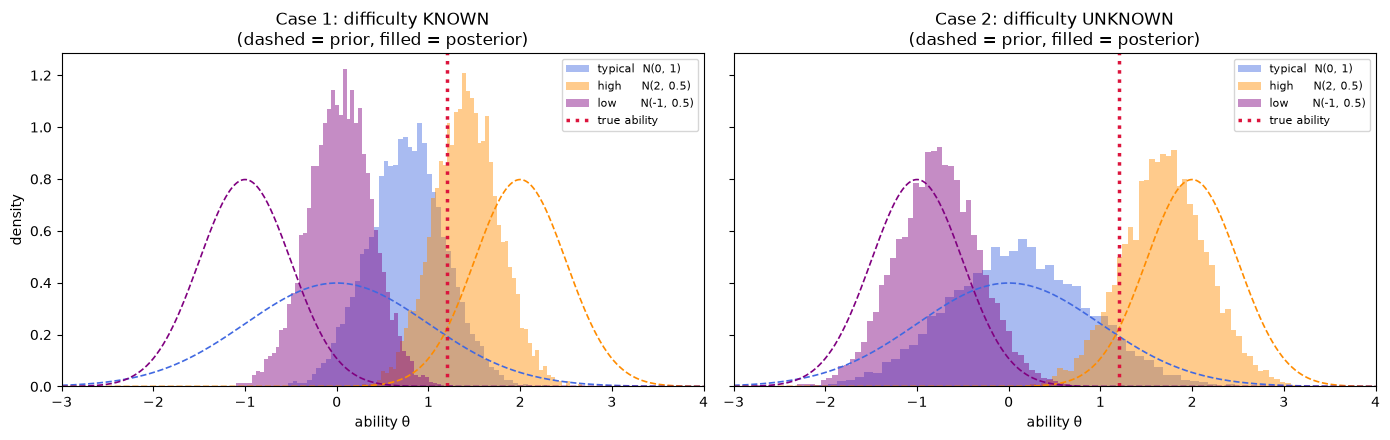

능력 θ의 사후분포 평균 (진짜 능력 1.2)
사전분포        난도를 앎       난도를 모름
보통           0.76         0.11
높게           1.42         1.70
낮게           0.04        -0.78


In [ ]:
priors = [("typical  N(0, 1)", 0.0, 1.0, "royalblue"),
          ("high     N(2, 0.5)", 2.0, 0.5, "darkorange"),
          ("low      N(-1, 0.5)", -1.0, 0.5, "purple")]
names_kr = {"typical  N(0, 1)": "보통", "high     N(2, 0.5)": "높게", "low      N(-1, 0.5)": "낮게"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
prior_results = {}
for label, m0, s0, col in priors:
    th_unk = fit_unknown(y, mu_theta=m0, sigma_theta=s0).stan_variable("theta")
    th_kn = fit_model(model_known, {"N": N, "y": y.tolist(), "delta": DELTA_TRUE,
                                    "mu_theta": m0, "sigma_theta": s0, "N_new": N_NEW}).stan_variable("theta")
    prior_results[label] = (th_kn, th_unk)
    for ax, th in [(axes[0], th_kn), (axes[1], th_unk)]:
        ax.plot(grid, norm.pdf(grid, m0, s0), color=col, linestyle="--", linewidth=1.2)
        ax.hist(th, bins=60, density=True, color=col, alpha=0.45, label=f"{label}")
for ax, title in [(axes[0], "Case 1: difficulty KNOWN"), (axes[1], "Case 2: difficulty UNKNOWN")]:
    ax.axvline(THETA_TRUE, color="crimson", linestyle=":", linewidth=2.5, label="true ability")
    ax.set_xlim(-3, 4)
    ax.set_xlabel("ability θ")
    ax.set_title(title + "\n(dashed = prior, filled = posterior)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

print("능력 θ의 사후분포 평균 (진짜 능력 1.2)")
print(f"{'사전분포':6s} {'난도를 앎':>10s} {'난도를 모름':>12s}")
for label, (th_kn, th_unk) in prior_results.items():
    print(f"{names_kr[label]:6s} {th_kn.mean():10.2f} {th_unk.mean():12.2f}")

**그림 읽기**

- **난도를 알 때 (왼쪽)**: 사후분포가 사전분포에서 데이터 쪽으로 분명히 움직입니다. "높게"(사전 평균 2)는 1.42로, "낮게"(사전 평균 −1)는 0.04로 옮겨 갔습니다.
  데이터가 사전분포의 치우침을 상당 부분 바로잡아 줍니다. 다만 20번은 많지 않아서 사전분포의 영향이 아직 남아 있습니다.
- **난도를 모를 때 (오른쪽)**: 사후분포가 각자의 사전분포 근처에 그대로 머뭅니다.
  "높게"는 2에서 1.70으로, "낮게"는 −1에서 −0.78로 조금 움직였을 뿐입니다. 높게 믿으면 높게, 낮게 믿으면 낮게 추정됩니다. **데이터가 이를 바로잡지 못합니다.**
  학생이 실제로 맞힌 개수는 똑같은데도 그렇습니다.
  이때 모델은 능력을 높게 믿으면 "문항이 어려웠나 보다", 낮게 믿으면 "문항이 쉬웠나 보다"라고 난도 쪽을 조정해서 같은 정답률을 설명합니다.

**정리**: 난도를 모르면 능력의 추정값은 사전분포에 크게 좌우됩니다. 그러므로 사전분포는 아무렇게나 정하면 안 되고,
"이 학생은 어떤 집단에 속하는가"처럼 근거가 있는 생각을 바탕으로 정해야 합니다.

## 7. 새 문항 10개를 풀면 몇 개를 맞힐까?

이제 이 학생이 **처음 보는 새 문항 10개**를 푼다고 합시다. 새 문항들의 난도는 모르지만, 보통 문항들처럼 평균 0, 표준편차 1인 정규분포 $N(0, 1)$ 을 따른다고 가정합니다.

예측은 다음 순서로 합니다. Stan 코드의 `generated quantities` 부분이 이 일을 합니다.
1. 사후분포에서 능력 값을 하나 뽑습니다.
2. 새 문항 10개의 난도를 뽑고, 각 문항을 맞힐지 틀릴지 정합니다.
3. 맞힌 개수를 셉니다.
4. 이 과정을 수천 번 반복해서 "몇 개를 맞힐지"의 분포를 얻습니다.

능력에 대한 불확실성과 새 문항마다 난도가 다르다는 점이 모두 예측에 반영됩니다.

경우 1 (난도를 앎)  : 평균 6.5개, 95% 범위 3~9개
경우 2 (난도를 모름): 평균 5.2개, 95% 범위 1~9개
참고: 진짜 능력 사용: 평균 7.3개, 95% 범위 4~10개


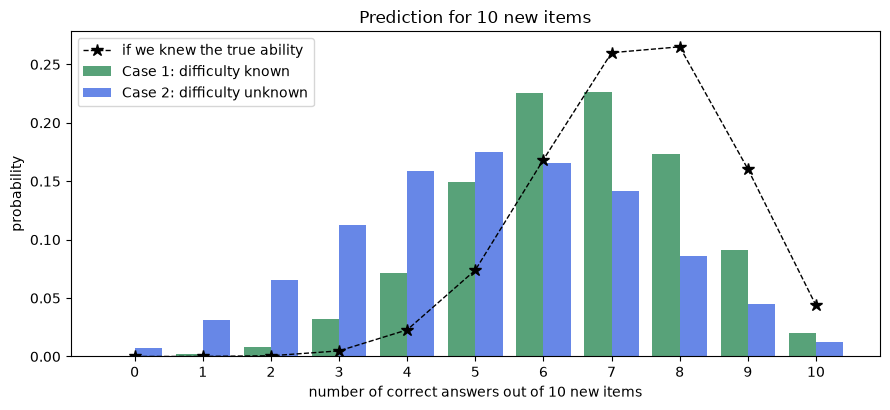

In [ ]:
xs = np.arange(N_NEW + 1)
def count_dist(samples):
    c = np.bincount(samples.astype(int), minlength=N_NEW + 1)
    return c / c.sum()

pred_known = fit_known.stan_variable("k_new")
pred_unk = fit_unk.stan_variable("k_new")

# (참고) 진짜 능력을 안다면 나올 분포 - 실제로는 알 수 없음
sim = np.random.default_rng(1).normal(0, 1, size=(200_000, N_NEW))
pred_true = np.random.default_rng(2).binomial(1, logistic(THETA_TRUE - sim)).sum(axis=1)

for name, s in [("경우 1 (난도를 앎)  ", pred_known), ("경우 2 (난도를 모름)", pred_unk),
                ("참고: 진짜 능력 사용", pred_true)]:
    lo, hi = np.quantile(s, [0.025, 0.975])
    print(f"{name}: 평균 {s.mean():.1f}개, 95% 범위 {lo:.0f}~{hi:.0f}개")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(xs - 0.2, count_dist(pred_known), width=0.4, color="seagreen", alpha=0.8, label="Case 1: difficulty known")
ax.bar(xs + 0.2, count_dist(pred_unk), width=0.4, color="royalblue", alpha=0.8, label="Case 2: difficulty unknown")
ax.plot(xs, count_dist(pred_true), "k*--", markersize=9, linewidth=1, label="if we knew the true ability")
ax.set_xticks(xs)
ax.set_xlabel(f"number of correct answers out of {N_NEW} new items")
ax.set_ylabel("probability")
ax.set_title(f"Prediction for {N_NEW} new items")
ax.legend()
plt.tight_layout()
plt.show()

**그림 읽기**

- 난도를 알 때는 평균 약 6.5개, 모를 때는 약 5.2개를 맞힐 것으로 예측합니다. 두 경우 모두 맞힐 개수의 범위가 꽤 넓습니다.
  학생의 능력도 확실히 모르고 새 문항의 난도도 제각각이기 때문입니다.
- **난도를 알 때(초록)** 의 예측이 진짜 능력으로 계산한 분포(별표)에 더 가깝습니다. 능력을 더 정확히 알기 때문입니다.
- **난도를 모를 때(파랑)** 의 예측은 능력의 사전분포에 크게 좌우됩니다.
  6절에서 "높게"를 썼다면 예측도 훨씬 높게, "낮게"를 썼다면 훨씬 낮게 나옵니다.
- 이번 데이터에서는 학생이 기대(62%)보다 조금 덜 맞혔기 때문에(55%), 두 예측 모두 진짜보다 조금 낮게 나왔습니다.

## 8. 정리

1. 정답 확률은 **능력과 난도의 차이**로 정해집니다: $\phi = \text{logistic}(\theta - \delta)$.
2. **난도를 알 때**는 응답 기록으로 능력을 추정할 수 있고, 많이 풀수록 더 정확해집니다.
3. **난도를 모를 때**는 한 문항의 응답 기록이 "차이"만 알려 줍니다. 같은 문항을 아무리 반복해도 능력 자체의 추정은 거의 나아지지 않습니다. (키 차이만 알고 각자의 키는 모르는 상황)
4. 그래서 난도를 모를 때는 **사전분포가 능력 추정값을 크게 좌우**합니다. 사전분포는 근거를 갖고 신중하게 정해야 합니다.
5. 새 문항에서의 정답 개수는 능력의 사후분포로 예측합니다. 능력에 대한 불확실성이 클수록 예측 범위도 넓어집니다.

실제 평가에서는 이런 이유로 **난도가 미리 정해진 문항을 쓰거나**, **여러 학생이 여러 문항을 풀게 해서** 능력과 난도를 함께 추정합니다.

## 9. 직접 해 보기 (연습 문제)

아래 값을 바꾼 뒤 노트북을 다시 실행해 보세요.

1. `SEED` 값을 바꿔 다른 응답 기록을 만들어 보세요. 정답률과 능력의 추정값이 어떻게 달라지나요?
2. `THETA_TRUE` 를 −1이나 2로 바꿔 보세요. 경우 1에서 추정값이 진짜 값을 잘 따라가나요? 경우 2에서는 어떤가요?
3. 6절의 "높게" 사전분포 대신 $N(0, 3)$ 처럼 아주 넓은 사전분포를 써 보세요. 경우 2의 능력 사후분포는 어떻게 되나요?
4. `N_BIG` 을 1000으로 늘려 보세요. 경우 1과 경우 2의 구간 폭은 각각 어떻게 변하나요?

더 깊이 알고 싶다면 심화용 노트북 `irt_1item_1person.ipynb` 를 보세요. 그 노트북에는 다음 내용이 수식과 함께 나옵니다.
- 같은 문항을 아무리 반복해도 능력의 불확실성이 일정 수준 아래로 줄지 않는 이유
- 난도를 모를 때 생기는 계산상의 문제(파라미터 표류, drift)와 그 해결 방법